<a href="https://colab.research.google.com/github/AnandVishwakarma24/CODOMAX/blob/main/Module-4-ML/Module_4_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4 — Machine Learning Fundamentals
## Student Score Prediction

**Goal:** Build a supervised machine learning regression model using Scikit-learn to predict a student's Final Score.

**Features:**
- Hours Studied
- Attendance
- Previous Score

**Target:**
- Final Score


## 1. Import Required Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Upload and Load the Dataset

Run this cell and select `student_scores.csv` from your computer.


In [8]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
df.head()


Saving student_scores.csv to student_scores.csv
Dataset loaded successfully.


,Hours Studied,Attendance,Previous Score,Final Score
0,5.1,59.3,50.7,29.54
1,11.5,77.1,49.8,37.48
2,9.1,93.6,89.4,61.49
3,7.6,86.6,50.0,28.53
4,2.7,90.3,51.3,36.07


## 3. Understand the Dataset

In [9]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()


Shape: (1000, 4)

Columns:
['Hours Studied', 'Attendance', 'Previous Score', 'Final Score']

Data types:
Hours Studied     float64
Attendance        float64
Previous Score    float64
Final Score       float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Hours Studied   1000 non-null   float64
 1   Attendance      1000 non-null   float64
 2   Previous Score  1000 non-null   float64
 3   Final Score     1000 non-null   float64
dtypes: float64(4)
memory usage: 31.4 KB


In [10]:
print("Statistical summary:")
df.describe()


Statistical summary:


,Hours Studied,Attendance,Previous Score,Final Score
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,6.392600,75.351200,65.144300,38.429680
std,3.214996,14.608042,17.440426,11.554285
min,1.100000,50.200000,35.000000,7.870000
25%,3.600000,62.075000,50.675000,30.125000
50%,6.500000,75.950000,65.000000,38.185000
75%,9.200000,88.000000,80.525000,47.032500
max,12.000000,100.000000,94.900000,66.540000


In [11]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
Hours Studied     0
Attendance        0
Previous Score    0
Final Score       0
dtype: int64

Duplicate rows: 0


## 4. Data Cleaning

In [12]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Convert columns to numeric values if necessary
numeric_columns = [
    "Hours Studied",
    "Attendance",
    "Previous Score",
    "Final Score"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Remove rows containing missing values
df = df.dropna().copy()

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Shape after cleaning: (1000, 4)

Missing values after cleaning:
Hours Studied     0
Attendance        0
Previous Score    0
Final Score       0
dtype: int64


## 5. Exploratory Data Analysis

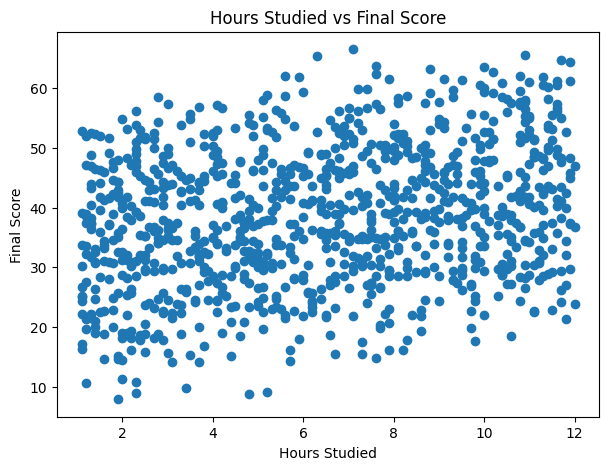

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Hours Studied"], df["Final Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.title("Hours Studied vs Final Score")
plt.show()


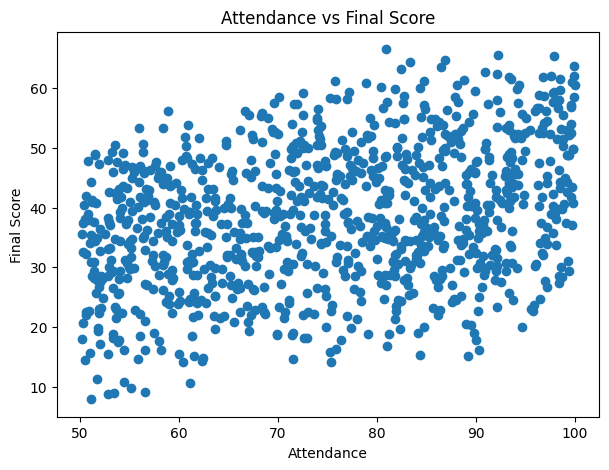

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Attendance"], df["Final Score"])
plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")
plt.show()


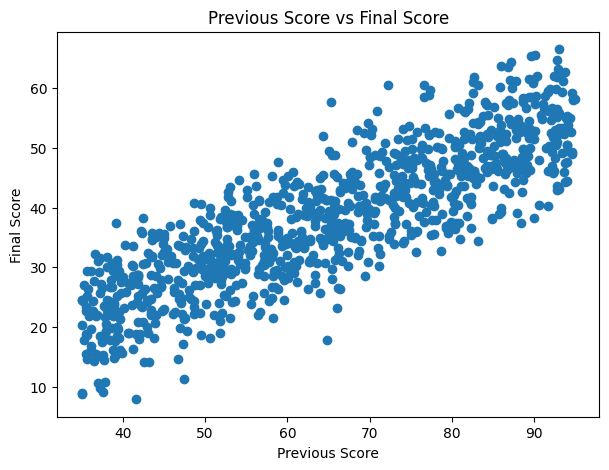

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Previous Score"], df["Final Score"])
plt.xlabel("Previous Score")
plt.ylabel("Final Score")
plt.title("Previous Score vs Final Score")
plt.show()


## 6. Select Features and Target

In [16]:
X = df[[
    "Hours Studied",
    "Attendance",
    "Previous Score"
]]

y = df["Final Score"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())


Features (X):
   Hours Studied  Attendance  Previous Score
0            5.1        59.3            50.7
1           11.5        77.1            49.8
2            9.1        93.6            89.4
3            7.6        86.6            50.0
4            2.7        90.3            51.3

Target (y):
0    29.54
1    37.48
2    61.49
3    28.53
4    36.07
Name: Final Score, dtype: float64


## 7. Split the Dataset into Training and Testing Sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 800
Testing samples: 200


## 8. Train the Machine Learning Model

We use **Linear Regression** because the target is a continuous numerical value.


In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed.")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Model training completed.
Intercept: -20.19503747833754
Coefficients: [0.86213895 0.22887322 0.55134785]


## 9. Make Predictions

In [19]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred.round(2)
})

results.head(10)


,Actual Score,Predicted Score
0,32.39,30.18
1,44.04,39.42
2,30.36,37.35
3,36.85,37.24
4,22.90,26.37
5,24.10,26.32
6,25.76,21.07
7,38.98,36.68
8,27.96,26.13
9,27.52,28.72


## 10. Evaluate the Model

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


MAE  : 3.51
MSE  : 17.76
RMSE : 4.21
R²   : 0.8845


### What the metrics mean

- **MAE:** Average absolute prediction error.
- **MSE:** Average squared prediction error.
- **RMSE:** Error measure in approximately the same units as the score.
- **R²:** Indicates how much variation in Final Score is explained by the model. A value closer to 1 is generally better.


## 11. Actual vs Predicted Visualization

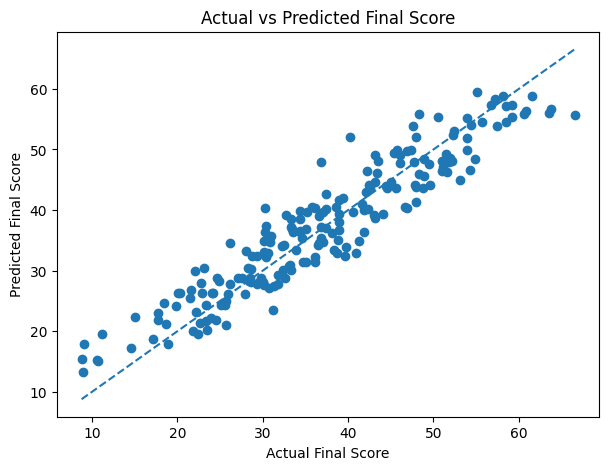

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)

# Ideal prediction line
min_score = min(y_test.min(), y_pred.min())
max_score = max(y_test.max(), y_pred.max())
plt.plot([min_score, max_score], [min_score, max_score], linestyle="--")

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")
plt.show()


## 12. Test the Model with a New Student

In [22]:
new_student = pd.DataFrame({
    "Hours Studied": [8],
    "Attendance": [90],
    "Previous Score": [75]
})

new_prediction = model.predict(new_student)[0]
new_prediction = float(np.clip(new_prediction, 0, 100))

print(f"Predicted Final Score: {new_prediction:.2f}")


Predicted Final Score: 48.65


## 13. Conclusion

The Student Score Prediction project demonstrates a complete basic machine learning workflow:

1. Loaded a dataset.
2. Inspected and cleaned the data.
3. Performed basic exploratory analysis.
4. Selected input features and target.
5. Split the data into training and testing sets.
6. Trained a Linear Regression model using Scikit-learn.
7. Generated predictions.
8. Evaluated the model using MAE, MSE, RMSE, and R².
9. Tested the model on a new student input.

**Submission:** Share this Google Colab notebook link.
